In [1]:
import os
from tensorboard.backend.event_processing import event_accumulator
log_file = "/home/luffy/sf2-rl-hw/artifacts/logs/baseline-10m/baseline-10m-20260609-092533/PPO_1/events.out.tfevents.1780968335.tn10.828680.0"
if not os.path.exists(log_file):
    print(f"❌ 錯誤：找不到該路徑下的檔案，請檢查路徑是否正確！")
else:
    print("⏳ 正在讀取 TensorBoard 原始二進位紀錄，請稍候...")
    # 初始化加載器，只讀取純量數據 (SCALARS)
    ea = event_accumulator.EventAccumulator(log_file, size_guidance={event_accumulator.SCALARS: 0})
    ea.Reload()
    print("\n✅ 讀取成功！你的 Log 檔案中包含以下所有指標 (Scalars)：")
    print("-" * 50)
    for i, tag in enumerate(ea.Tags()['scalars'], 1):
        print(f"{i:02d}. {tag}")
    print("-" * 50)

⏳ 正在讀取 TensorBoard 原始二進位紀錄，請稍候...

✅ 讀取成功！你的 Log 檔案中包含以下所有指標 (Scalars)：
--------------------------------------------------
01. time/fps
02. train/approx_kl
03. train/clip_fraction
04. train/clip_range
05. train/entropy_loss
06. train/explained_variance
07. train/learning_rate
08. train/loss
09. train/policy_gradient_loss
10. train/value_loss
--------------------------------------------------


✅ 數據對齊完成！總共 1220 筆核心數據紀錄。

👇 你的核心指標數據預覽 (Step | Policy | Value | Entropy)：


,Step,Policy_Loss,Value_Loss,Entropy_Loss
0,16384,-0.000405,4.206659,-8.313517
1,24576,-0.000004,2.823035,-8.310465
2,32768,0.001113,5.167395,-8.308110
3,40960,-0.001126,2.636829,-8.308707
4,49152,0.000667,2.870416,-8.299891
5,57344,-0.001769,2.229982,-8.304644
6,65536,0.000110,2.342578,-8.299647
7,73728,-0.003060,1.786507,-8.291007
8,81920,-0.003018,1.853737,-8.291409
9,90112,-0.000663,1.950284,-8.286943


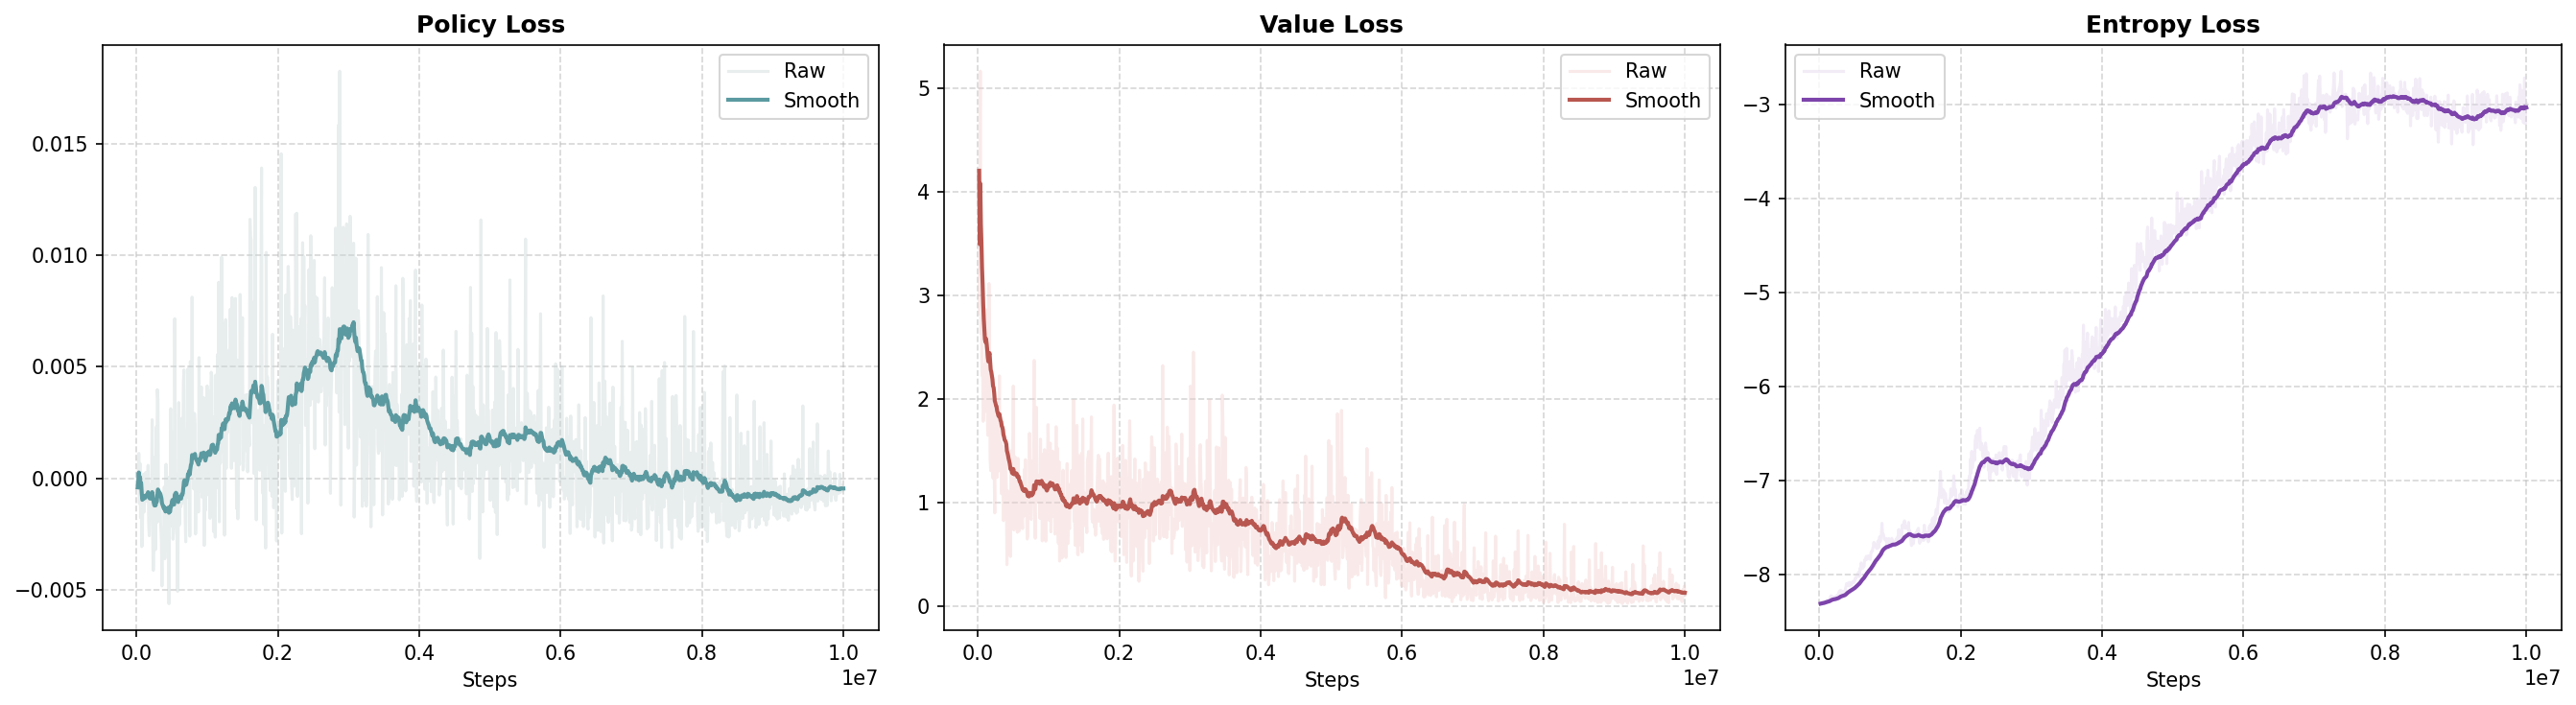

圖表已成功儲存為 'ppo_core_metrics.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 提取四大核心變數
entropy_raw = ea.Scalars('train/entropy_loss')
value_raw = ea.Scalars('train/value_loss')
policy_raw = ea.Scalars('train/policy_gradient_loss')

# 2. 建立精簡版 DataFrame
df = pd.DataFrame({
    "Step": [e.step for e in entropy_raw],
    "Policy_Loss": [e.value for e in policy_raw],
    "Value_Loss": [e.value for e in value_raw],
    "Entropy_Loss": [e.value for e in entropy_raw]
})

print(f"✅ 數據對齊完成！總共 {len(df)} 筆核心數據紀錄。")
print("\n👇 你的核心指標數據預覽 (Step | Policy | Value | Entropy)：")
display(df.head(10))

# =====================================================================
# 3. 繪製簡報/論文專用：三合一收斂對比圖
# =====================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# --- 1. Policy Gradient Loss ---
ax1.plot(df["Step"], df["Policy_Loss"], color="#c7d3d4", alpha=0.4, label="Raw")
ax1.plot(df["Step"], df["Policy_Loss"].ewm(alpha=0.05).mean(), color="#5b9aa0", linewidth=2, label="Smooth")
ax1.set_title("Policy Loss", fontsize=12, fontweight='bold')
ax1.set_xlabel("Steps")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

# --- 2. Value Loss ---
ax2.plot(df["Step"], df["Value_Loss"], color="#f1cbca", alpha=0.4, label="Raw")
ax2.plot(df["Step"], df["Value_Loss"].ewm(alpha=0.05).mean(), color="#b85750", linewidth=2, label="Smooth")
ax2.set_title("Value Loss", fontsize=12, fontweight='bold')
ax2.set_xlabel("Steps")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

# --- 3. Entropy Loss ---
ax3.plot(df["Step"], df["Entropy_Loss"], color="#e0d1eb", alpha=0.4, label="Raw")
ax3.plot(df["Step"], df["Entropy_Loss"].ewm(alpha=0.05).mean(), color="#7d44ab", linewidth=2, label="Smooth")
ax3.set_title("Entropy Loss", fontsize=12, fontweight='bold')
ax3.set_xlabel("Steps")
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.savefig("ppo_core_metrics.png", bbox_inches='tight')
plt.show()
print("圖表已成功儲存為 'ppo_core_metrics.png'")

In [3]:
import os
import json
import pandas as pd

# 1. 設定你的基本路徑
base_dir = "/home/luffy/sf2-rl-hw/artifacts/eval/baseline-10m/baseline-10m-20260609-092533"

results = []

# 2. 自動遍歷該目錄下的所有檔案夾
for folder_name in os.listdir(base_dir):
    # 檢查資料夾名稱是否以 step_ 開頭
    if folder_name.startswith("step_"):
        try:
            # 提取 step 的數字
            step_num = int(folder_name.split("_")[1])
            
            # 拼接 metrics.json 的完整路徑
            json_path = os.path.join(base_dir, folder_name, "metrics.json")
            
            # 檢查該 json 檔案是否存在
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    data = json.load(f)
                    
                    # 抓出你需要的關鍵數據
                    win_rate = data.get("win_rate")
                    hp_diff = data.get("mean_final_hp_diff")
                    
                    # 暫存結果
                    results.append({
                        "Step": step_num,
                        "Win Rate": win_rate,
                        "Mean Final HP Diff": hp_diff
                    })
        except (ValueError, IndexError):
            # 避免有其他奇怪名字的 step 資料夾導致報錯
            continue

# 3. 將結果轉換為 Pandas DataFrame 並按照 Step 排序（從 50萬、100萬 一路排下去）
df = pd.DataFrame(results)
df = df.sort_values(by="Step").reset_index(drop=True)

# 4. 印出結果，並存成 CSV 檔方便你丟進 Excel 做圖
print("--- 數據抓取成功 ---")
print(df.to_string(index=False))

output_csv = os.path.join(base_dir, "summary_metrics.csv")
df.to_csv(output_csv, index=False)
print(f"\n已將完整數據儲存至: {output_csv}")

--- 數據抓取成功 ---
    Step  Win Rate  Mean Final HP Diff
  500000       0.0              -159.0
 1000000       0.0               -72.0
 1500000       0.0               -68.0
 2000000       0.0              -131.0
 2500000       0.0              -177.0
 3000000       0.0              -177.0
 3500000       0.0               -68.0
 4000000       0.0              -177.0
 4500000       0.0              -177.0
 5000000       0.0              -177.0
 5500000       0.0              -177.0
 6000000       0.0              -127.0
 6500000       0.0               -48.0
 7000000       0.0               -48.0
 7500000       0.0               -67.0
 8000000       1.0                65.0
 8500000       0.0               -16.0
 9000000       0.0               -51.0
 9500000       1.0                19.0
10000000       1.0                19.0
10002432       1.0                19.0

已將完整數據儲存至: /home/luffy/sf2-rl-hw/artifacts/eval/baseline-10m/baseline-10m-20260609-092533/summary_metrics.csv


🎉 專業趨勢圖已繪製成功！儲存路徑：/home/luffy/sf2-rl-hw/artifacts/eval/baseline-10m/baseline-10m-20260609-092533/evaluation_trend.png


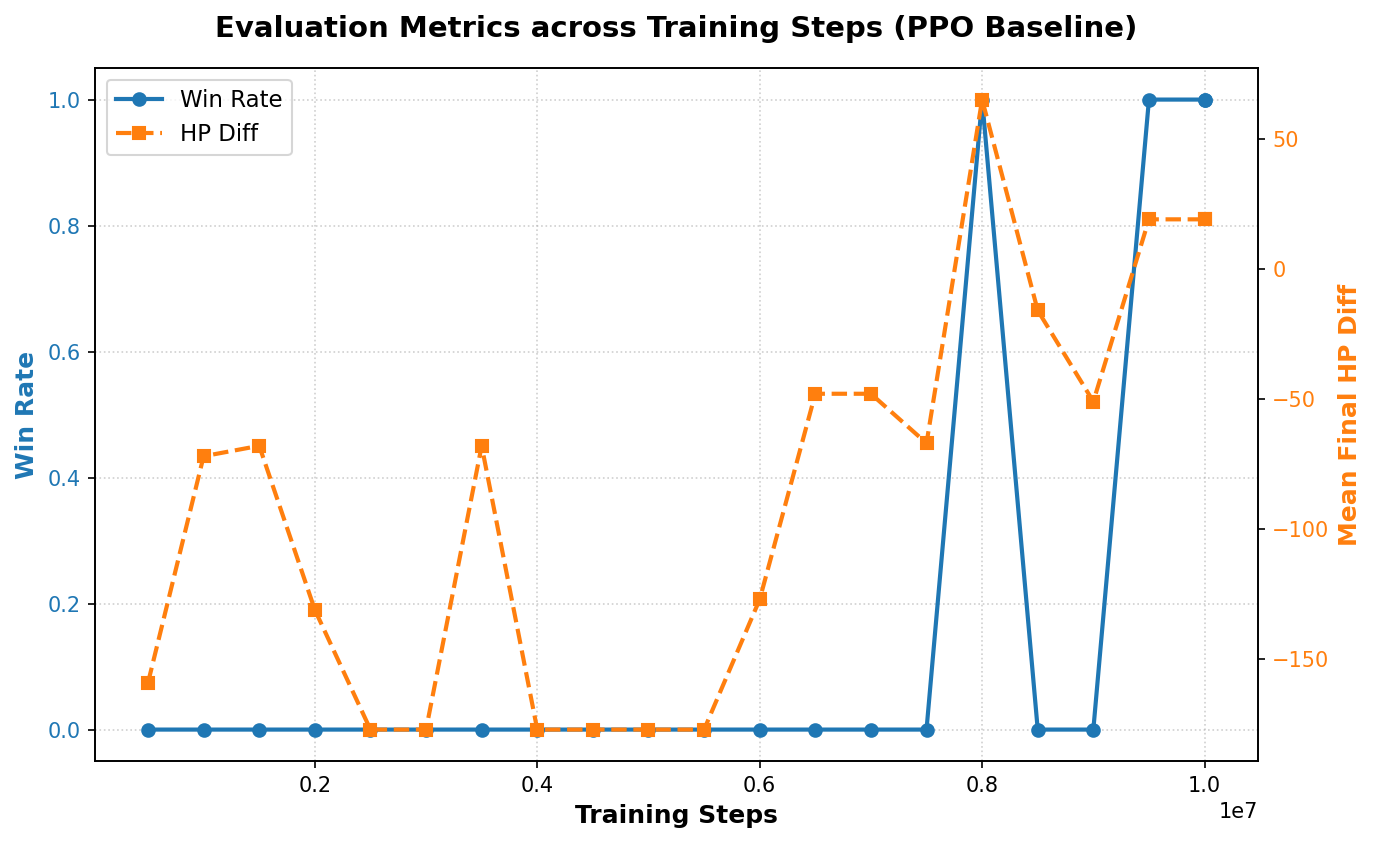

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. 讀取你剛剛抓好的數據（假設檔名為 summary_metrics.csv）
csv_path = "/home/luffy/sf2-rl-hw/artifacts/eval/baseline-10m/baseline-10m-20260609-092533/summary_metrics.csv"
df = pd.read_csv(csv_path)
df = df.sort_values(by="Step")  # 確保由小到大排序

# 2. 開始畫圖
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# --- 畫左邊的 Y 軸：Win Rate ---
color = '#1f77b4'  # 經典學術藍
ax1.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
ax1.set_ylabel('Win Rate', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(df['Step'], df['Win Rate'], color=color, marker='o', linewidth=2, label='Win Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(-0.05, 1.05)  # 勝率範圍固定在 0~1 之間

# --- 畫右邊的 Y 軸：Mean Final HP Diff ---
ax2 = ax1.twinx()  # 關鍵：建立共享 X 軸的雙 Y 軸
color = '#ff7f0e'  # 溫暖橘
ax2.set_ylabel('Mean Final HP Diff', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(df['Step'], df['Mean Final HP Diff'], color=color, marker='s', linestyle='--', linewidth=2, label='HP Diff')
ax2.tick_params(axis='y', labelcolor=color)

# --- 圖表細節優化（讓教授挑不出毛病） ---
# 合併兩條線的圖例 (Legend)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Evaluation Metrics across Training Steps (PPO Baseline)', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)  # 加上淡淡的網格線

# 儲存圖片
output_png = os.path.join(os.path.dirname(csv_path), "evaluation_trend.png")
plt.savefig(output_png, bbox_inches='tight')
print(f"🎉 專業趨勢圖已繪製成功！儲存路徑：{output_png}")
plt.show()